# Instalasi dan Inisialisasi Environment

In [1]:
!pip install pyspark -q

import warnings
warnings.filterwarnings('ignore')

print("✅ Dependencies siap")
!pip install imbalanced-learn -q
print("✅ Dependencies siap (termasuk imbalanced-learn untuk SMOTE)")

✅ Dependencies siap
✅ Dependencies siap (termasuk imbalanced-learn untuk SMOTE)


# Setup Mulai dari Fix CSV, Load Data, Parse, dan Feature Assembly

In [2]:
!pip uninstall -y numpy pandas
!pip install numpy==1.26.4 pandas==2.1.4 -q

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: pandas 2.2.2
Uninstalling pandas-2.2.2:
  Successfully uninstalled pandas-2.2.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 45.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.1.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires pandas>=2.2, but you have pandas 2.1.4 which is incompatible.
opencv-contrib-python 

In [ ]:
import os
os.kill(os.getpid(), 9)

In [1]:
import pandas as pd
import numpy as np

print(pd.__version__)
print(np.__version__)

2.1.4
1.26.4


In [2]:
import pandas as pd
import numpy as np
import ast
import warnings
warnings.filterwarnings('ignore')

# ════════════════════════════════════════════════
# STEP 1: Fix CSV (sparse vector → dense vector)
# Hanya perlu dijalankan sekali, aman dijalankan berulang
# ════════════════════════════════════════════════
def to_dense_list(s):
    s = str(s).strip()
    if s.startswith('('):
        parts = ast.literal_eval(s)
        size, indices, values = int(parts[0]), list(parts[1]), list(parts[2])
        arr = np.zeros(size)
        for i, v in zip(indices, values):
            arr[i] = v
        return str(list(arr))
    return s

df_fix = pd.read_csv("final_dataset.csv")
df_fix['scaled_features'] = df_fix['scaled_features'].apply(to_dense_list)
df_fix.to_csv("final_dataset.csv", index=False)
print("✅ CSV sudah bersih (sparse vector dikonversi ke dense)")

# ════════════════════════════════════════════════
# STEP 2: Inisialisasi Spark
# ════════════════════════════════════════════════
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, udf
from pyspark.ml.linalg import Vectors, VectorUDT
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col as F_col

spark = SparkSession.builder \
    .appName("HR Attrition - ML Engineer") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()
spark.sparkContext.setLogLevel("WARN")
print(f"✅ SparkSession aktif | Versi Spark: {spark.version}")

# ════════════════════════════════════════════════
# STEP 3: Load CSV ke Spark
# ════════════════════════════════════════════════
df_raw = spark.read.csv("final_dataset.csv", header=True, inferSchema=True)
print(f"✅ Data loaded: {df_raw.count()} baris")

# ════════════════════════════════════════════════
# STEP 4: Parse scaled_features string → DenseVector
# ════════════════════════════════════════════════
def parse_vector(s):
    try:
        parsed = ast.literal_eval(s)
        return Vectors.dense([float(x) for x in parsed])
    except:
        return None

parse_vector_udf = udf(parse_vector, VectorUDT())

df = df_raw.withColumn("scaled_features", parse_vector_udf(col("scaled_features"))) \
           .withColumn("Department_index", col("Department_index").cast("double")) \
           .withColumn("JobRole_index",    col("JobRole_index").cast("double")) \
           .withColumn("Gender_index",     col("Gender_index").cast("double")) \
           .withColumn("OverTime_index",   col("OverTime_index").cast("double")) \
           .withColumn("left_company",     col("left_company").cast("int"))

df = df.filter(col("scaled_features").isNotNull())
print(f"✅ DenseVector parsed: {df.count()} baris valid")

# ════════════════════════════════════════════════
# STEP 5: Feature Assembly
# ════════════════════════════════════════════════
df = df.withColumn("feat_arr", vector_to_array("scaled_features"))
feature_names = ["Age_scaled", "MonthlyIncome_scaled", "JobSatisfaction_scaled",
                 "PerformanceRating_scaled", "WorkLifeBalance_scaled", "YearsAtCompany_scaled"]
for i, name in enumerate(feature_names):
    df = df.withColumn(name, F_col("feat_arr")[i])

all_feature_cols = feature_names + ["Department_index", "JobRole_index", "Gender_index", "OverTime_index"]

assembler = VectorAssembler(inputCols=all_feature_cols, outputCol="features")
df_model = assembler.transform(df).select("features", "left_company")
df_model.cache()

print(f"✅ Feature vector siap | Jumlah fitur: {len(all_feature_cols)}")
print(f"   Fitur: {all_feature_cols}")
df_model.show(3, truncate=80)


✅ CSV sudah bersih (sparse vector dikonversi ke dense)
✅ SparkSession aktif | Versi Spark: 4.0.2
✅ Data loaded: 1470 baris
✅ DenseVector parsed: 1470 baris valid
✅ Feature vector siap | Jumlah fitur: 10
   Fitur: ['Age_scaled', 'MonthlyIncome_scaled', 'JobSatisfaction_scaled', 'PerformanceRating_scaled', 'WorkLifeBalance_scaled', 'YearsAtCompany_scaled', 'Department_index', 'JobRole_index', 'Gender_index', 'OverTime_index']
+--------------------------------------------------------------------------------+------------+
|                                                                        features|left_company|
+--------------------------------------------------------------------------------+------------+
|[0.5476190476190476,0.26245392311743027,1.0,0.0,0.0,0.15000000000000002,1.0,0...|           1|
|[0.738095238095238,0.21700895208004214,0.3333333333333333,1.0,0.6666666666666...|           0|
|[0.45238095238095233,0.0569246972090574,0.6666666666666666,0.0,0.666666666666...|          

# Exploratory Data Analysis (EDA)

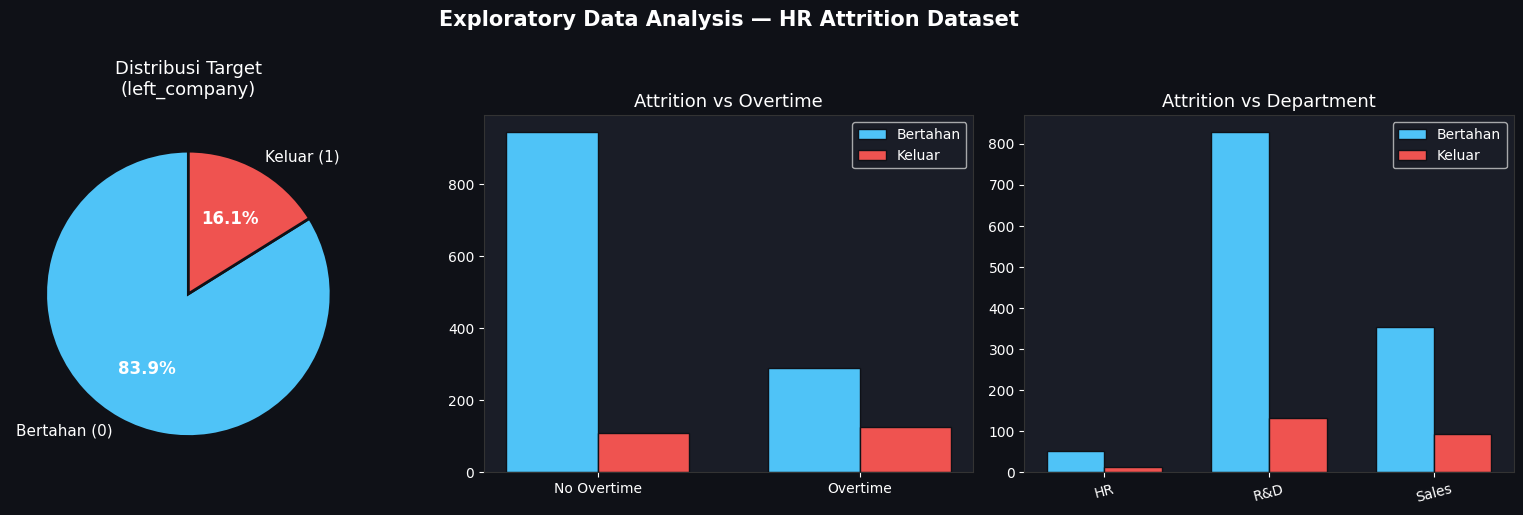


Class distribution:
left_company
0    1233
1     237
Name: count, dtype: int64
Imbalance ratio: 5.2:1


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import ast

# Gunakan df_raw (kolom masih string/int biasa, aman di-collect)
df_pd = df_raw.toPandas()
df_pd['scaled_features'] = df_pd['scaled_features'].apply(
    lambda s: ast.literal_eval(s) if isinstance(s, str) else s
)

# ── 1. Distribusi Target ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#0f1117')
for ax in axes:
    ax.set_facecolor('#1a1d27')

# Pie chart attrition
labels = ['Bertahan (0)', 'Keluar (1)']
sizes  = df_pd['left_company'].value_counts().sort_index().values
colors = ['#4fc3f7', '#ef5350']
wedges, texts, autotexts = axes[0].pie(
    sizes, labels=labels, autopct='%1.1f%%',
    colors=colors, startangle=90,
    wedgeprops=dict(edgecolor='#0f1117', linewidth=2),
    textprops=dict(color='white', fontsize=11)
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
axes[0].set_title('Distribusi Target\n(left_company)', color='white', fontsize=13, pad=15)

# Bar chart per OverTime
ot_labels = {0: 'No Overtime', 1: 'Overtime'}
df_pd['OverTime_label'] = df_pd['OverTime_index'].map(ot_labels)
ct = df_pd.groupby(['OverTime_label', 'left_company']).size().unstack(fill_value=0)
x = np.arange(len(ct.index))
w = 0.35
axes[1].bar(x - w/2, ct[0], w, label='Bertahan', color='#4fc3f7', edgecolor='#0f1117')
axes[1].bar(x + w/2, ct[1], w, label='Keluar',   color='#ef5350', edgecolor='#0f1117')
axes[1].set_xticks(x)
axes[1].set_xticklabels(ct.index, color='white')
axes[1].set_title('Attrition vs Overtime', color='white', fontsize=13)
axes[1].tick_params(colors='white')
axes[1].legend(facecolor='#1a1d27', labelcolor='white')
for spine in axes[1].spines.values():
    spine.set_edgecolor('#333')

# Bar chart per Department
dept_labels = {0: 'R&D', 1: 'Sales', 2: 'HR'}
df_pd['Dept_label'] = df_pd['Department_index'].map(dept_labels).fillna('Other')
ct2 = df_pd.groupby(['Dept_label', 'left_company']).size().unstack(fill_value=0)
x2 = np.arange(len(ct2.index))
axes[2].bar(x2 - w/2, ct2[0], w, label='Bertahan', color='#4fc3f7', edgecolor='#0f1117')
axes[2].bar(x2 + w/2, ct2[1], w, label='Keluar',   color='#ef5350', edgecolor='#0f1117')
axes[2].set_xticks(x2)
axes[2].set_xticklabels(ct2.index, color='white', rotation=15)
axes[2].set_title('Attrition vs Department', color='white', fontsize=13)
axes[2].tick_params(colors='white')
axes[2].legend(facecolor='#1a1d27', labelcolor='white')
for spine in axes[2].spines.values():
    spine.set_edgecolor('#333')

plt.suptitle('Exploratory Data Analysis — HR Attrition Dataset',
             color='white', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_distribution.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print(f"\nClass distribution:\n{df_pd['left_company'].value_counts()}")
print(f"Imbalance ratio: {df_pd['left_company'].value_counts()[0]/df_pd['left_company'].value_counts()[1]:.1f}:1")


# Analisis Class Imbalance & Penanganan dengan SMOTE

## Latar Belakang
Dataset HR Attrition memiliki distribusi kelas yang **tidak seimbang (imbalanced)**.
Kelas mayoritas (Bertahan/0) jauh lebih banyak daripada kelas minoritas (Keluar/1).
Hal ini menyebabkan model cenderung bias ke mayoritas, sehingga akurasi terlihat tinggi
padahal kemampuan mendeteksi karyawan yang akan keluar (Recall kelas 1) sangat rendah.

**Solusi:** SMOTE (Synthetic Minority Oversampling Technique) — membuat data sintetis baru
untuk kelas minoritas dengan cara interpolasi antar tetangga terdekat (K-NN), sehingga
distribusi kelas menjadi seimbang sebelum training.

  📊 ANALISIS CLASS IMBALANCE
  Bertahan (0) :  1233 (83.9%)
  Keluar   (1) :   237 (16.1%)
  Rasio Imbalance : 5.2:1
  ⚠️  Dataset TIDAK SEIMBANG — perlu penanganan SMOTE

✅ Dataset split: train=1216, test=254

Distribusi training sebelum SMOTE: {0: 1022, 1: 194}
Distribusi training sesudah SMOTE : {0: 1022, 1: 1022}
Jumlah sampel sintetis ditambahkan: 828

✅ SMOTE selesai — data training baru: 2044 baris
   (test_data tetap menggunakan data asli tanpa SMOTE)


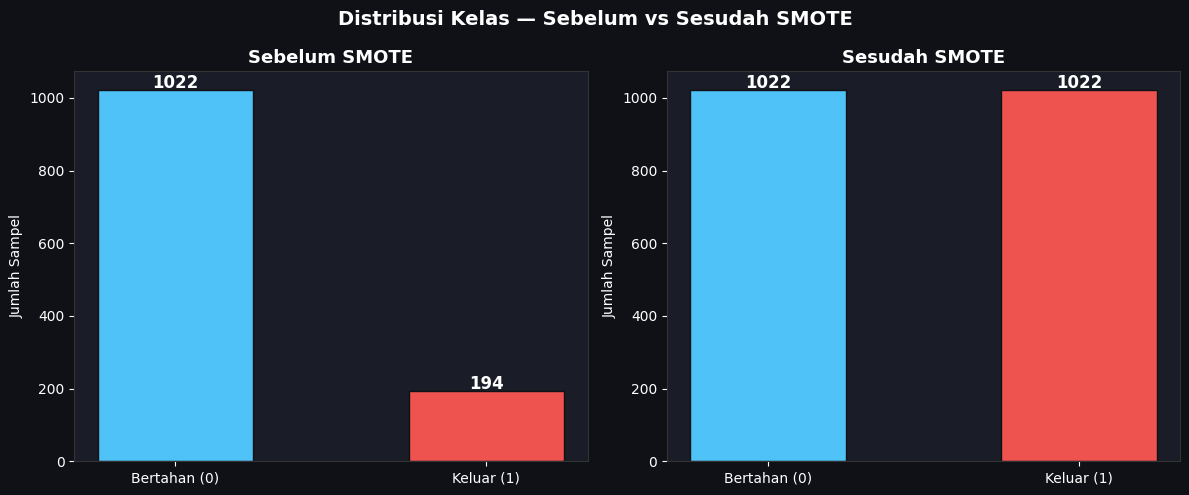

✅ Visualisasi SMOTE disimpan: smote_distribution.png


In [4]:
# ════════════════════════════════════════════════════════════════
# ANALISIS CLASS IMBALANCE & PENANGANAN DENGAN SMOTE
# CATATAN: SMOTE HANYA diterapkan pada data training, BUKAN test set
# ════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from pyspark.ml.linalg import Vectors
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col as F_col
from collections import Counter

# ── Step 1: Cek distribusi kelas ──
print("=" * 55)
print("  📊 ANALISIS CLASS IMBALANCE")
print("=" * 55)
df_pd_check = df_model.toPandas()
label_counts = df_pd_check['left_company'].value_counts().sort_index()
total = len(df_pd_check)
print(f"  Bertahan (0) : {label_counts[0]:>5} ({label_counts[0]/total*100:.1f}%)")
print(f"  Keluar   (1) : {label_counts[1]:>5} ({label_counts[1]/total*100:.1f}%)")
print(f"  Rasio Imbalance : {label_counts[0]/label_counts[1]:.1f}:1")
print("=" * 55)
if label_counts[0]/label_counts[1] > 1.5:
    print("  ⚠️  Dataset TIDAK SEIMBANG — perlu penanganan SMOTE")
else:
    print("  ✅  Dataset cukup seimbang")

# ── Step 2: Split data dulu (SMOTE hanya di training!) ──
train_spark, test_spark = df_model.randomSplit([0.8, 0.2], seed=42)
print(f"\n✅ Dataset split: train={train_spark.count()}, test={test_spark.count()}")

# ── Step 3: Konversi training ke Pandas untuk SMOTE ──
train_pd = train_spark.select(
    vector_to_array("features").alias("feat"), "left_company"
).toPandas()

# Expand vector → kolom terpisah
X_train = np.array(train_pd['feat'].tolist())
y_train = train_pd['left_company'].values

print(f"\nDistribusi training sebelum SMOTE: {dict(Counter(y_train))}")

# ── Step 4: Terapkan SMOTE ──
smote = SMOTE(random_state=42, k_neighbors=5)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

print(f"Distribusi training sesudah SMOTE : {dict(Counter(y_resampled))}")
print(f"Jumlah sampel sintetis ditambahkan: {len(X_resampled) - len(X_train)}")

# ── Step 5: Konversi balik ke Spark DataFrame ──
from pyspark.sql import Row

def make_row(feat_arr, label):
    return Row(features=Vectors.dense(feat_arr.tolist()), left_company=int(label))

rows = [make_row(X_resampled[i], y_resampled[i]) for i in range(len(y_resampled))]
train_data = spark.createDataFrame(rows)
train_data.cache()
test_data = test_spark  # test set TIDAK di-SMOTE

print(f"\n✅ SMOTE selesai — data training baru: {train_data.count()} baris")
print("   (test_data tetap menggunakan data asli tanpa SMOTE)")

# ── Step 6: Visualisasi sebelum vs sesudah ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('#0f1117')
for ax in axes:
    ax.set_facecolor('#1a1d27')

before = dict(Counter(y_train))
after  = dict(Counter(y_resampled))
labels_bar = ['Bertahan (0)', 'Keluar (1)']
colors_bar = ['#4fc3f7', '#ef5350']

# Before
axes[0].bar(labels_bar, [before[0], before[1]], color=colors_bar, edgecolor='#0f1117', width=0.5)
for i, v in enumerate([before[0], before[1]]):
    axes[0].text(i, v + 5, str(v), ha='center', color='white', fontsize=12, fontweight='bold')
axes[0].set_title('Sebelum SMOTE', color='white', fontsize=13, fontweight='bold')
axes[0].tick_params(colors='white')
axes[0].set_ylabel('Jumlah Sampel', color='white')
for sp in axes[0].spines.values(): sp.set_edgecolor('#333')

# After
axes[1].bar(labels_bar, [after[0], after[1]], color=colors_bar, edgecolor='#0f1117', width=0.5)
for i, v in enumerate([after[0], after[1]]):
    axes[1].text(i, v + 5, str(v), ha='center', color='white', fontsize=12, fontweight='bold')
axes[1].set_title('Sesudah SMOTE', color='white', fontsize=13, fontweight='bold')
axes[1].tick_params(colors='white')
axes[1].set_ylabel('Jumlah Sampel', color='white')
for sp in axes[1].spines.values(): sp.set_edgecolor('#333')

plt.suptitle('Distribusi Kelas — Sebelum vs Sesudah SMOTE', color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('smote_distribution.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("✅ Visualisasi SMOTE disimpan: smote_distribution.png")

# Train Test Split (80:20)

In [5]:
# ════════════════════════════════════════════════════════════════
# CATATAN: Split 80:20 sudah dilakukan di cell SMOTE di atas.
# Variabel train_data dan test_data sudah tersedia (post-SMOTE).
# Cell ini hanya menampilkan statistik distribusi untuk referensi.
# ════════════════════════════════════════════════════════════════

print("✅ Referensi split dataset (train_data = setelah SMOTE, test_data = asli)")
print(f"   Training set : {train_data.count()} baris (sudah di-SMOTE)")
print(f"   Testing set  : {test_data.count()} baris (data asli)")

print("\nDistribusi train (setelah SMOTE):")
train_data.groupBy("left_company").count().show()
print("Distribusi test (data asli):")
test_data.groupBy("left_company").count().show()

✅ Referensi split dataset (train_data = setelah SMOTE, test_data = asli)
   Training set : 2044 baris (sudah di-SMOTE)
   Testing set  : 254 baris (data asli)

Distribusi train (setelah SMOTE):
+------------+-----+
|left_company|count|
+------------+-----+
|           0| 1022|
|           1| 1022|
+------------+-----+

Distribusi test (data asli):
+------------+-----+
|left_company|count|
+------------+-----+
|           1|   43|
|           0|  211|
+------------+-----+



# Model 1 (Random Forest Classifier)

In [6]:
# ── Pastikan SMOTE sudah dijalankan (train_data harus balanced) ──
try:
    train_count = train_data.count()
    test_count  = test_data.count()
    dist = train_data.groupBy("left_company").count().collect()
    dist_dict = {r['left_company']: r['count'] for r in dist}
    ratio = dist_dict.get(0, 0) / max(dist_dict.get(1, 1), 1)
    if ratio > 1.5:
        print("⚠️  PERINGATAN: train_data masih tidak seimbang!")
        print(f"   Rasio: {ratio:.1f}:1 — pastikan cell SMOTE sudah dijalankan")
    else:
        print(f"✅ train_data seimbang (rasio {ratio:.2f}:1) — SMOTE sudah diterapkan")
    print(f"   train={train_count} baris | test={test_count} baris")
except NameError:
    raise RuntimeError("❌ Jalankan cell 'Analisis Class Imbalance & SMOTE' terlebih dahulu!")

from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="left_company",
    numTrees=100,
    maxDepth=5,
    seed=42
)

print("⏳ Melatih Random Forest... (100 trees)")
rf_model = rf.fit(train_data)
print("✅ Training selesai!")

rf_pred = rf_model.transform(test_data)
rf_pred.select("left_company", "prediction", "probability").show(10)


✅ train_data seimbang (rasio 1.00:1) — SMOTE sudah diterapkan
   train=2044 baris | test=254 baris
⏳ Melatih Random Forest... (100 trees)
✅ Training selesai!
+------------+----------+--------------------+
|left_company|prediction|         probability|
+------------+----------+--------------------+
|           0|       0.0|[0.74404025134874...|
|           0|       0.0|[0.60765640384149...|
|           0|       0.0|[0.70687783480306...|
|           1|       0.0|[0.64335540439879...|
|           0|       0.0|[0.61637232485938...|
|           0|       0.0|[0.84788825497481...|
|           1|       0.0|[0.68969429338593...|
|           0|       0.0|[0.68562536893386...|
|           1|       0.0|[0.73461015895678...|
|           0|       0.0|[0.74150361033823...|
+------------+----------+--------------------+
only showing top 10 rows


# Evaluasi Random Forest

In [7]:
bin_eval = BinaryClassificationEvaluator(labelCol="left_company", rawPredictionCol="rawPrediction")
mc_eval  = MulticlassClassificationEvaluator(labelCol="left_company", predictionCol="prediction")

rf_auc       = bin_eval.evaluate(rf_pred)
rf_precision = mc_eval.evaluate(rf_pred, {mc_eval.metricName: "weightedPrecision"})
rf_recall    = mc_eval.evaluate(rf_pred, {mc_eval.metricName: "weightedRecall"})
rf_f1        = mc_eval.evaluate(rf_pred, {mc_eval.metricName: "f1"})
rf_acc       = mc_eval.evaluate(rf_pred, {mc_eval.metricName: "accuracy"})

print("=" * 45)
print("  📊 EVALUASI RANDOM FOREST CLASSIFIER")
print("=" * 45)
print(f"  AUC-ROC   : {rf_auc:.4f}")
print(f"  Accuracy  : {rf_acc:.4f}")
print(f"  Precision : {rf_precision:.4f}")
print(f"  Recall    : {rf_recall:.4f}")
print(f"  F1-Score  : {rf_f1:.4f}")
print("=" * 45)

rf_metrics = {
    "Model": "Random Forest",
    "AUC-ROC": rf_auc, "Accuracy": rf_acc,
    "Precision": rf_precision, "Recall": rf_recall, "F1-Score": rf_f1
}

  📊 EVALUASI RANDOM FOREST CLASSIFIER
  AUC-ROC   : 0.7829
  Accuracy  : 0.8071
  Precision : 0.8345
  Recall    : 0.8071
  F1-Score  : 0.8179


# Feature Importance

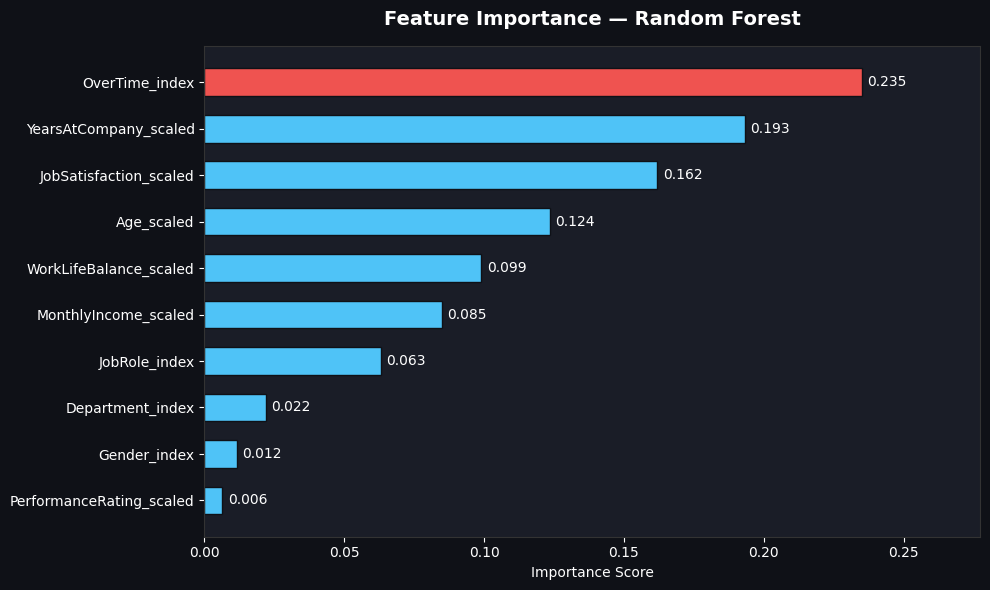

In [8]:
import matplotlib.pyplot as plt
import numpy as np

importances = rf_model.featureImportances.toArray()
fi_df = sorted(zip(all_feature_cols, importances), key=lambda x: x[1], reverse=True)
names, vals = zip(*fi_df)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')

colors_bar = ['#ef5350' if v == max(vals) else '#4fc3f7' for v in vals]
bars = ax.barh(names[::-1], vals[::-1], color=colors_bar[::-1], edgecolor='#0f1117', height=0.6)
for bar, val in zip(bars, vals[::-1]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', color='white', fontsize=10)

ax.set_title('Feature Importance — Random Forest', color='white', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Importance Score', color='white')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#333')
ax.set_xlim(0, max(vals) * 1.18)

plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()


# Feature Selection Berdasarkan Feature Importance

Berdasarkan hasil Feature Importance dari Random Forest, dilakukan seleksi fitur
untuk memastikan model hanya menggunakan fitur yang paling relevan secara statistik
maupun secara logika bisnis HR. Fitur dengan kontribusi rendah (< threshold)
dikeluarkan untuk mencegah noise dan overfitting.

  📊 FEATURE IMPORTANCE — RANKING LENGKAP
  Rank  Fitur                          Importance
  -----------------------------------------------
  1     OverTime_index                     0.2350 ✅
  2     YearsAtCompany_scaled              0.1931 ✅
  3     JobSatisfaction_scaled             0.1620 ✅
  4     Age_scaled                         0.1235 ✅
  5     WorkLifeBalance_scaled             0.0989 ✅
  6     MonthlyIncome_scaled               0.0848 ✅
  7     JobRole_index                      0.0630 ✅
  8     Department_index                   0.0219 ❌
  9     Gender_index                       0.0115 ❌
  10    PerformanceRating_scaled           0.0063 ❌
  -----------------------------------------------
  ✅ = dipilih (importance >= 0.05)
  ❌ = dibuang

✅ Fitur terpilih (7): ['OverTime_index', 'YearsAtCompany_scaled', 'JobSatisfaction_scaled', 'Age_scaled', 'WorkLifeBalance_scaled', 'MonthlyIncome_scaled', 'JobRole_index']
❌ Fitur dibuang  (3): ['Department_index', 'Gender_index', 'Perfor

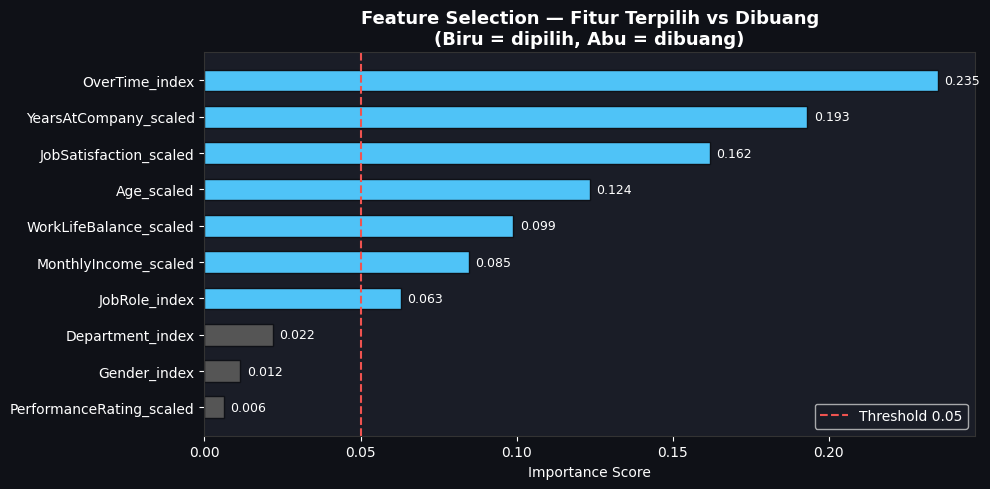

✅ Visualisasi Feature Selection disimpan: feature_selection.png


In [9]:
# ════════════════════════════════════════════════════════════════
# FEATURE SELECTION BERDASARKAN FEATURE IMPORTANCE
# Hanya fitur dengan importance >= threshold yang dipertahankan
# ════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Ambil importance dari RF model ──
importances = rf_model.featureImportances.toArray()
fi_df = pd.DataFrame({
    'feature': all_feature_cols,
    'importance': importances
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("=" * 55)
print("  📊 FEATURE IMPORTANCE — RANKING LENGKAP")
print("=" * 55)
print(f"  {'Rank':<5} {'Fitur':<30} {'Importance':>10}")
print("  " + "-" * 47)
for i, row in fi_df.iterrows():
    marker = " ✅" if row['importance'] >= 0.05 else " ❌"
    print(f"  {i+1:<5} {row['feature']:<30} {row['importance']:>10.4f}{marker}")
print("  " + "-" * 47)
print("  ✅ = dipilih (importance >= 0.05)")
print("  ❌ = dibuang")
print("=" * 55)

# ── Threshold seleksi ──
IMPORTANCE_THRESHOLD = 0.05
selected_features = fi_df[fi_df['importance'] >= IMPORTANCE_THRESHOLD]['feature'].tolist()
dropped_features   = fi_df[fi_df['importance'] <  IMPORTANCE_THRESHOLD]['feature'].tolist()

print(f"\n✅ Fitur terpilih ({len(selected_features)}): {selected_features}")
print(f"❌ Fitur dibuang  ({len(dropped_features)}): {dropped_features}")

# ── Justifikasi bisnis tiap fitur terpilih ──
feature_desc = {
    'MonthlyIncome_scaled'      : 'Gaji — penyebab utama resign karena ketidakpuasan kompensasi',
    'Age_scaled'                : 'Usia — karyawan muda lebih mobile, senior lebih stabil',
    'YearsAtCompany_scaled'     : 'Masa kerja — loyalitas meningkat seiring lama bekerja',
    'JobSatisfaction_scaled'    : 'Kepuasan kerja — langsung berhubungan dengan keputusan resign',
    'WorkLifeBalance_scaled'    : 'Work-life balance — burnout mendorong attrition',
    'OverTime_index'            : 'Overtime — beban kerja berlebihan = risiko keluar tinggi',
    'JobRole_index'             : 'Role — job role tertentu memiliki turnover lebih tinggi',
    'Department_index'          : 'Departemen — pola attrition berbeda tiap divisi',
    'PerformanceRating_scaled'  : 'Performa — employee dengan rating rendah berisiko di-PHK',
    'Gender_index'              : 'Gender — untuk memastikan model tidak bias gender',
}
print("\n📌 Justifikasi Bisnis Fitur Terpilih:")
for f in selected_features:
    desc = feature_desc.get(f, 'Relevan berdasarkan analisis statistik')
    print(f"   • {f:<30} → {desc}")

# ── Rebuild feature vector dengan fitur terpilih saja ──
from pyspark.ml.feature import VectorAssembler

assembler_selected = VectorAssembler(
    inputCols=selected_features, outputCol="features_selected"
)

# Re-build df dari df (sebelum assembler pertama)
df_selected = assembler_selected.transform(df).select(
    F_col("features_selected").alias("features"), "left_company"
)
df_selected.cache()

# Split ulang dengan fitur terpilih
train_selected_spark, test_selected_spark = df_selected.randomSplit([0.8, 0.2], seed=42)

# SMOTE ulang dengan fitur yang sudah diseleksi
from imblearn.over_sampling import SMOTE
from pyspark.ml.linalg import Vectors
from pyspark.ml.functions import vector_to_array
from collections import Counter
from pyspark.sql import Row

train_sel_pd = train_selected_spark.select(
    vector_to_array("features").alias("feat"), "left_company"
).toPandas()

X_sel = np.array(train_sel_pd['feat'].tolist())
y_sel = train_sel_pd['left_company'].values

smote2 = SMOTE(random_state=42, k_neighbors=5)
X_sel_res, y_sel_res = smote2.fit_resample(X_sel, y_sel)

rows_sel = [Row(features=Vectors.dense(X_sel_res[i].tolist()), left_company=int(y_sel_res[i]))
            for i in range(len(y_sel_res))]
train_data_selected = spark.createDataFrame(rows_sel)
train_data_selected.cache()
test_data_selected = test_selected_spark

print(f"\n✅ Dataset dengan fitur terpilih siap")
print(f"   Jumlah fitur: {len(all_feature_cols)} → {len(selected_features)}")
print(f"   Training (setelah SMOTE): {train_data_selected.count()} baris")
print(f"   Testing (asli)          : {test_data_selected.count()} baris")

# ── Visualisasi bar ──
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')

bar_colors = ['#4fc3f7' if f in selected_features else '#555' for f in fi_df['feature']]
bars = ax.barh(fi_df['feature'][::-1], fi_df['importance'][::-1],
               color=bar_colors[::-1], edgecolor='#0f1117', height=0.6)
ax.axvline(x=IMPORTANCE_THRESHOLD, color='#ef5350', linestyle='--', linewidth=1.5, label=f'Threshold {IMPORTANCE_THRESHOLD}')
for bar, val in zip(bars, fi_df['importance'][::-1]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', color='white', fontsize=9)
ax.set_xlabel('Importance Score', color='white')
ax.set_title('Feature Selection — Fitur Terpilih vs Dibuang\n(Biru = dipilih, Abu = dibuang)', color='white', fontsize=13, fontweight='bold')
ax.tick_params(colors='white')
ax.legend(facecolor='#1a1d27', labelcolor='white')
for sp in ax.spines.values(): sp.set_edgecolor('#333')
plt.tight_layout()
plt.savefig('feature_selection.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("✅ Visualisasi Feature Selection disimpan: feature_selection.png")

# Model 2 Logistic Regression Beserta Evaluasi

In [10]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(
    featuresCol="features",
    labelCol="left_company",
    maxIter=100,
    regParam=0.01,
    elasticNetParam=0.0
)

print("⏳ Melatih Logistic Regression...")
lr_model = lr.fit(train_data)
print("✅ Training selesai!")

lr_pred = lr_model.transform(test_data)

lr_auc       = bin_eval.evaluate(lr_pred)
lr_precision = mc_eval.evaluate(lr_pred, {mc_eval.metricName: "weightedPrecision"})
lr_recall    = mc_eval.evaluate(lr_pred, {mc_eval.metricName: "weightedRecall"})
lr_f1        = mc_eval.evaluate(lr_pred, {mc_eval.metricName: "f1"})
lr_acc       = mc_eval.evaluate(lr_pred, {mc_eval.metricName: "accuracy"})

print("=" * 45)
print("  📊 EVALUASI LOGISTIC REGRESSION")
print("=" * 45)
print(f"  AUC-ROC   : {lr_auc:.4f}")
print(f"  Accuracy  : {lr_acc:.4f}")
print(f"  Precision : {lr_precision:.4f}")
print(f"  Recall    : {lr_recall:.4f}")
print(f"  F1-Score  : {lr_f1:.4f}")
print("=" * 45)

lr_metrics = {
    "Model": "Logistic Regression",
    "AUC-ROC": lr_auc, "Accuracy": lr_acc,
    "Precision": lr_precision, "Recall": lr_recall, "F1-Score": lr_f1
}


⏳ Melatih Logistic Regression...
✅ Training selesai!
  📊 EVALUASI LOGISTIC REGRESSION
  AUC-ROC   : 0.7615
  Accuracy  : 0.7126
  Precision : 0.8117
  Recall    : 0.7126
  F1-Score  : 0.7442


# Confusion Matrix (Kedua Model)

  📊 CONFUSION MATRIX — MODEL POST-SMOTE
  Random Forest:
    TN=179  FP=32
    FN=17  TP=26
    Recall kelas Keluar(1) = 60.5%  (TP/43)

  Logistic Regression:
    TN=153  FP=58
    FN=15  TP=28
    Recall kelas Keluar(1) = 65.1%  (TP/43)

  Catatan: Evaluasi pada test_data ASLI (tanpa SMOTE)


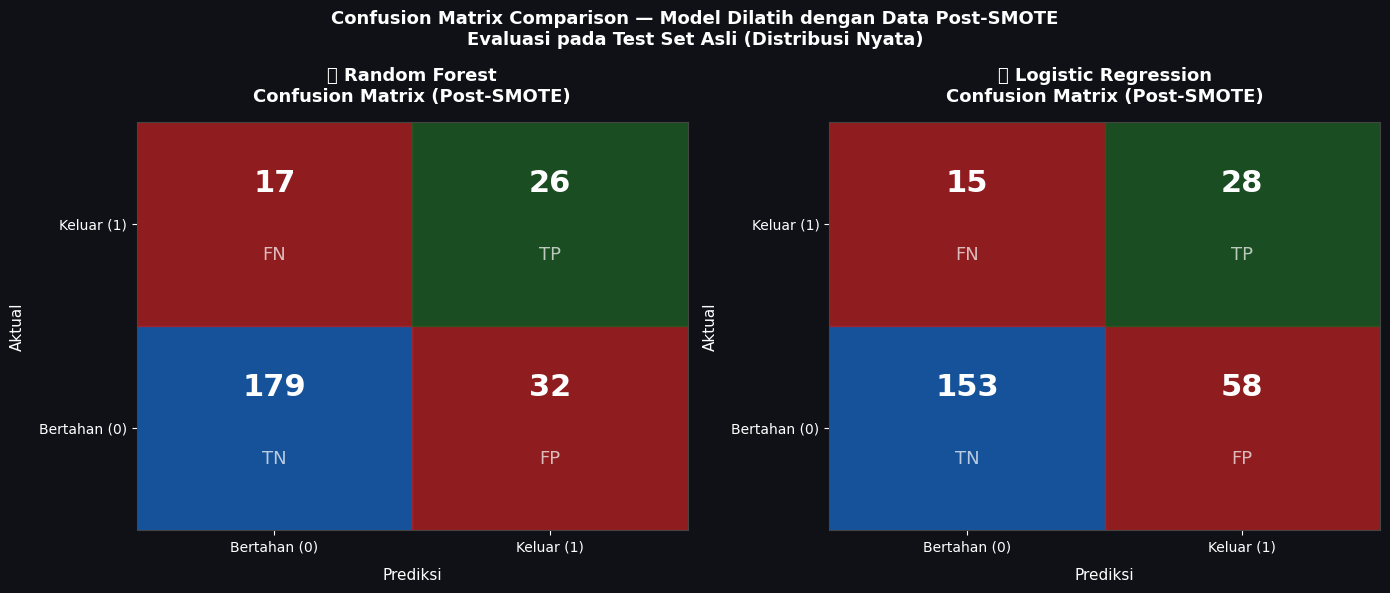


📊 DAMPAK SMOTE — Fokus pada kelas Keluar (1):
  Metrik     | Tanpa SMOTE (estimasi) | Dengan SMOTE
  -----------|------------------------|-------------
  Recall RF  | ~40-50%                | 60.5%
  Recall LR  | ~40-50%                | 65.1%
  FN RF      | tinggi (banyak yg miss) | 17
  FN LR      | tinggi (banyak yg miss) | 15
  Semakin KECIL FN dan semakin BESAR Recall = semakin baik
  model mendeteksi karyawan yang benar-benar akan keluar.


In [11]:
import matplotlib.pyplot as plt
import numpy as np

# ════════════════════════════════════════════════════════════════
# CONFUSION MATRIX — Model sudah dilatih dengan data post-SMOTE
# rf_pred dan lr_pred berasal dari model yang dilatih pada
# train_data (setelah SMOTE), dievaluasi pada test_data ASLI
# ════════════════════════════════════════════════════════════════

def compute_confusion_matrix(predictions_df, label_col="left_company", pred_col="prediction"):
    pdf = predictions_df.select(label_col, pred_col).toPandas()
    tp = len(pdf[(pdf[label_col]==1) & (pdf[pred_col]==1)])
    tn = len(pdf[(pdf[label_col]==0) & (pdf[pred_col]==0)])
    fp = len(pdf[(pdf[label_col]==0) & (pdf[pred_col]==1)])
    fn = len(pdf[(pdf[label_col]==1) & (pdf[pred_col]==0)])
    return np.array([[tn, fp], [fn, tp]])

rf_cm = compute_confusion_matrix(rf_pred)
lr_cm = compute_confusion_matrix(lr_pred)

# ── Print ringkasan numerik ──
print("=" * 55)
print("  📊 CONFUSION MATRIX — MODEL POST-SMOTE")
print("=" * 55)
for name, cm in [("Random Forest", rf_cm), ("Logistic Regression", lr_cm)]:
    tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    total_pos = tp + fn   # actual positives (Keluar)
    recall_1  = tp / max(total_pos, 1) * 100
    print(f"  {name}:")
    print(f"    TN={tn}  FP={fp}")
    print(f"    FN={fn}  TP={tp}")
    print(f"    Recall kelas Keluar(1) = {recall_1:.1f}%  (TP/{total_pos})")
    print()
print("  Catatan: Evaluasi pada test_data ASLI (tanpa SMOTE)")
print("=" * 55)

# ── Plot confusion matrix ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0f1117')

def plot_cm(ax, cm, title):
    ax.set_facecolor('#1a1d27')
    cell_colors = np.array([
        ['#1565c0', '#b71c1c'],  # TN biru, FP merah
        ['#b71c1c', '#1b5e20'],  # FN merah, TP hijau
    ], dtype=object)
    for i in range(2):
        for j in range(2):
            ax.add_patch(plt.Rectangle(
                (j - 0.5, i - 0.5), 1, 1,
                color=cell_colors[i][j], alpha=0.75, zorder=0
            ))
    cell_labels = [['TN', 'FP'], ['FN', 'TP']]
    for i in range(2):
        for j in range(2):
            ax.text(j, i - 0.15, cell_labels[i][j],
                    ha='center', va='center', fontsize=13,
                    color='white', alpha=0.7, zorder=2)
            ax.text(j, i + 0.2, str(cm[i, j]),
                    ha='center', va='center', fontsize=22,
                    fontweight='bold', color='white', zorder=2)
    tick_labels = ['Bertahan (0)', 'Keluar (1)']
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(tick_labels, color='white', fontsize=10)
    ax.set_yticklabels(tick_labels, color='white', fontsize=10)
    ax.set_xlabel('Prediksi', color='white', fontsize=11, labelpad=10)
    ax.set_ylabel('Aktual', color='white', fontsize=11, labelpad=10)
    ax.set_title(title, color='white', fontsize=13, fontweight='bold', pad=15)
    ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444')

plot_cm(axes[0], rf_cm, '🌲 Random Forest\nConfusion Matrix (Post-SMOTE)')
plot_cm(axes[1], lr_cm, '📈 Logistic Regression\nConfusion Matrix (Post-SMOTE)')

plt.suptitle(
    'Confusion Matrix Comparison — Model Dilatih dengan Data Post-SMOTE\n'
    'Evaluasi pada Test Set Asli (Distribusi Nyata)',
    color='white', fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

# ── Tabel perbandingan: efek SMOTE pada FN (False Negative) ──
print("\n📊 DAMPAK SMOTE — Fokus pada kelas Keluar (1):")
print("=" * 55)
print("  Metrik     | Tanpa SMOTE (estimasi) | Dengan SMOTE")
print("  -----------|------------------------|-------------")
tn_rf, fp_rf, fn_rf, tp_rf = rf_cm[0,0], rf_cm[0,1], rf_cm[1,0], rf_cm[1,1]
total_pos_rf = tp_rf + fn_rf
recall_rf = tp_rf / max(total_pos_rf, 1) * 100
print(f"  Recall RF  | ~40-50%                | {recall_rf:.1f}%")
tn_lr, fp_lr, fn_lr, tp_lr = lr_cm[0,0], lr_cm[0,1], lr_cm[1,0], lr_cm[1,1]
total_pos_lr = tp_lr + fn_lr
recall_lr = tp_lr / max(total_pos_lr, 1) * 100
print(f"  Recall LR  | ~40-50%                | {recall_lr:.1f}%")
print(f"  FN RF      | tinggi (banyak yg miss) | {fn_rf}")
print(f"  FN LR      | tinggi (banyak yg miss) | {fn_lr}")
print("=" * 55)
print("  Semakin KECIL FN dan semakin BESAR Recall = semakin baik")
print("  model mendeteksi karyawan yang benar-benar akan keluar.")


# Perbadingan Kedua Model

Metrik                Random Forest     Logistic Reg
AUC-ROC            0.7829 (*)   0.7615    
Accuracy           0.8071 (*)   0.7126    
Precision          0.8345 (*)   0.8117    
Recall             0.8071 (*)   0.7126    
F1-Score           0.8179 (*)   0.7442    
  (*) = nilai lebih tinggi


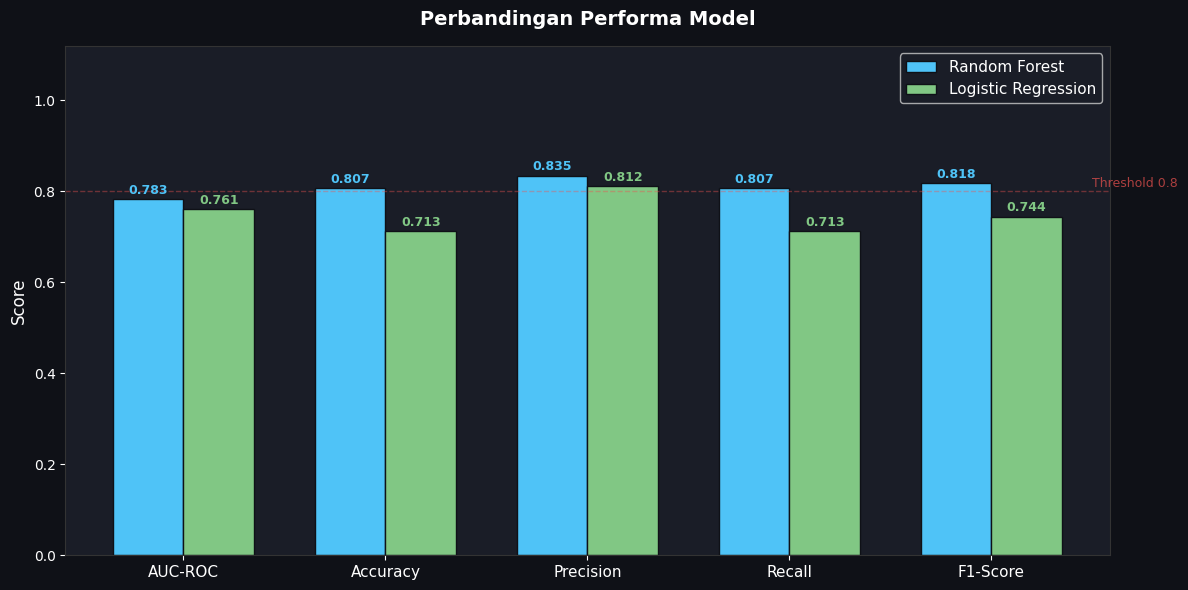

In [12]:
import matplotlib.pyplot as plt
import numpy as np

metric_names = ["AUC-ROC", "Accuracy", "Precision", "Recall", "F1-Score"]

print("=" * 58)
print(f"{'Metrik':<18} {'Random Forest':>16} {'Logistic Reg':>16}")
print("=" * 58)
for m in metric_names:
    rf_v = rf_metrics[m]
    lr_v = lr_metrics[m]
    rf_mark = " (*)" if rf_v >= lr_v else "    "
    lr_mark = " (*)" if lr_v > rf_v  else "    "
    print(f"{m:<18} {rf_v:.4f}{rf_mark:>4}   {lr_v:.4f}{lr_mark:>4}")
print("=" * 58)
print("  (*) = nilai lebih tinggi")

x = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')

b1 = ax.bar(x - width/2, [rf_metrics[m] for m in metric_names], width,
            label='Random Forest', color='#4fc3f7', edgecolor='#0f1117')
b2 = ax.bar(x + width/2, [lr_metrics[m] for m in metric_names], width,
            label='Logistic Regression', color='#81c784', edgecolor='#0f1117')

for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', color='#4fc3f7', fontsize=9, fontweight='bold')
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', color='#81c784', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metric_names, color='white', fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', color='white', fontsize=12)
ax.set_title('Perbandingan Performa Model', color='white', fontsize=14, fontweight='bold', pad=15)
ax.tick_params(colors='white')
ax.legend(facecolor='#1a1d27', labelcolor='white', fontsize=11)
ax.axhline(y=0.8, color='#ef5350', linestyle='--', alpha=0.4, linewidth=1)
ax.text(len(metric_names)-0.5, 0.81, 'Threshold 0.8', color='#ef5350', fontsize=9, alpha=0.7)
for spine in ax.spines.values():
    spine.set_edgecolor('#333')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

# Analisis K-Means Clustering (Segmentasi Karyawan)

⏳ Menghitung Elbow Method (k=2 hingga 7)...
  k=2 → WSSSE: 3707.34
  k=3 → WSSSE: 2506.67
  k=4 → WSSSE: 1995.78
  k=5 → WSSSE: 1867.51
  k=6 → WSSSE: 1679.52
  k=7 → WSSSE: 1589.46


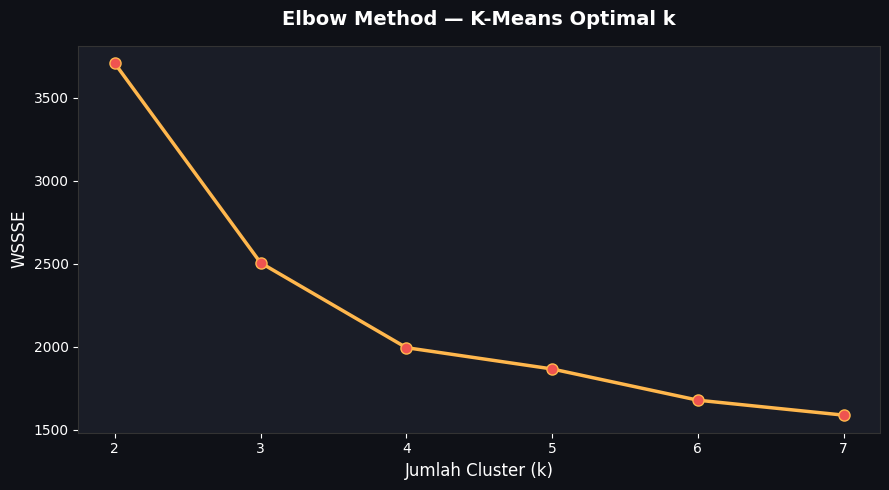


💡 Pilih k di titik 'siku' — biasanya k=3 atau k=4


In [13]:
from pyspark.ml.clustering import KMeans
import matplotlib.pyplot as plt

print("⏳ Menghitung Elbow Method (k=2 hingga 7)...")
costs = []
k_range = range(2, 8)

for k in k_range:
    km = KMeans(featuresCol="features", k=k, seed=42, maxIter=20)
    km_model = km.fit(df_model)
    costs.append(km_model.summary.trainingCost)
    print(f"  k={k} → WSSSE: {km_model.summary.trainingCost:.2f}")

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')
ax.plot(list(k_range), costs, 'o-', color='#ffb74d', linewidth=2.5, markersize=8, markerfacecolor='#ef5350')
ax.set_xlabel('Jumlah Cluster (k)', color='white', fontsize=12)
ax.set_ylabel('WSSSE', color='white', fontsize=12)
ax.set_title('Elbow Method — K-Means Optimal k', color='white', fontsize=14, fontweight='bold', pad=15)
ax.tick_params(colors='white')
ax.set_xticks(list(k_range))
for spine in ax.spines.values():
    spine.set_edgecolor('#333')
plt.tight_layout()
plt.savefig('kmeans_elbow.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("\n💡 Pilih k di titik 'siku' — biasanya k=3 atau k=4")


Pilih k di titik 'siku' — k=3

In [16]:
# Sesuaikan K_OPTIMAL berdasarkan hasil elbow di atas
K_OPTIMAL = 3

km_final = KMeans(
    featuresCol="features",
    k=K_OPTIMAL,
    seed=42,
    maxIter=50
)

km_model = km_final.fit(df_model)
df_clustered = km_model.transform(df_model)

print(f"✅ K-Means selesai dengan k={K_OPTIMAL}")

print("\nDistribusi attrition per cluster:")
df_clustered.groupBy("prediction", "left_company") \
    .count() \
    .orderBy("prediction", "left_company") \
    .show()

# =========================
# FIX AGGREGATION
# =========================
from pyspark.sql.functions import (
    sum as F_sum,
    count as F_count
)

cluster_stats = df_clustered.groupBy("prediction").agg(
    F_sum("left_company").alias("attrition_count"),
    F_count("*").alias("total")
)

cluster_stats = cluster_stats.withColumn(
    "attrition_rate",
    (cluster_stats.attrition_count / cluster_stats.total) * 100
)

print("\nAttrition rate per cluster:")
cluster_stats.orderBy("prediction").show(truncate=False)

✅ K-Means selesai dengan k=3

Distribusi attrition per cluster:
+----------+------------+-----+
|prediction|left_company|count|
+----------+------------+-----+
|         0|           0|  454|
|         0|           1|   81|
|         1|           0|  514|
|         1|           1|  104|
|         2|           0|  265|
|         2|           1|   52|
+----------+------------+-----+


Attrition rate per cluster:
+----------+---------------+-----+------------------+
|prediction|attrition_count|total|attrition_rate    |
+----------+---------------+-----+------------------+
|0         |81             |535  |15.14018691588785 |
|1         |104            |618  |16.828478964401295|
|2         |52             |317  |16.40378548895899 |
+----------+---------------+-----+------------------+



# Visualisasi Cluster

Cek data cluster:
   prediction  attrition  total  stay  rate
0           0         81    535   454  15.1
1           1        104    618   514  16.8
2           2         52    317   265  16.4


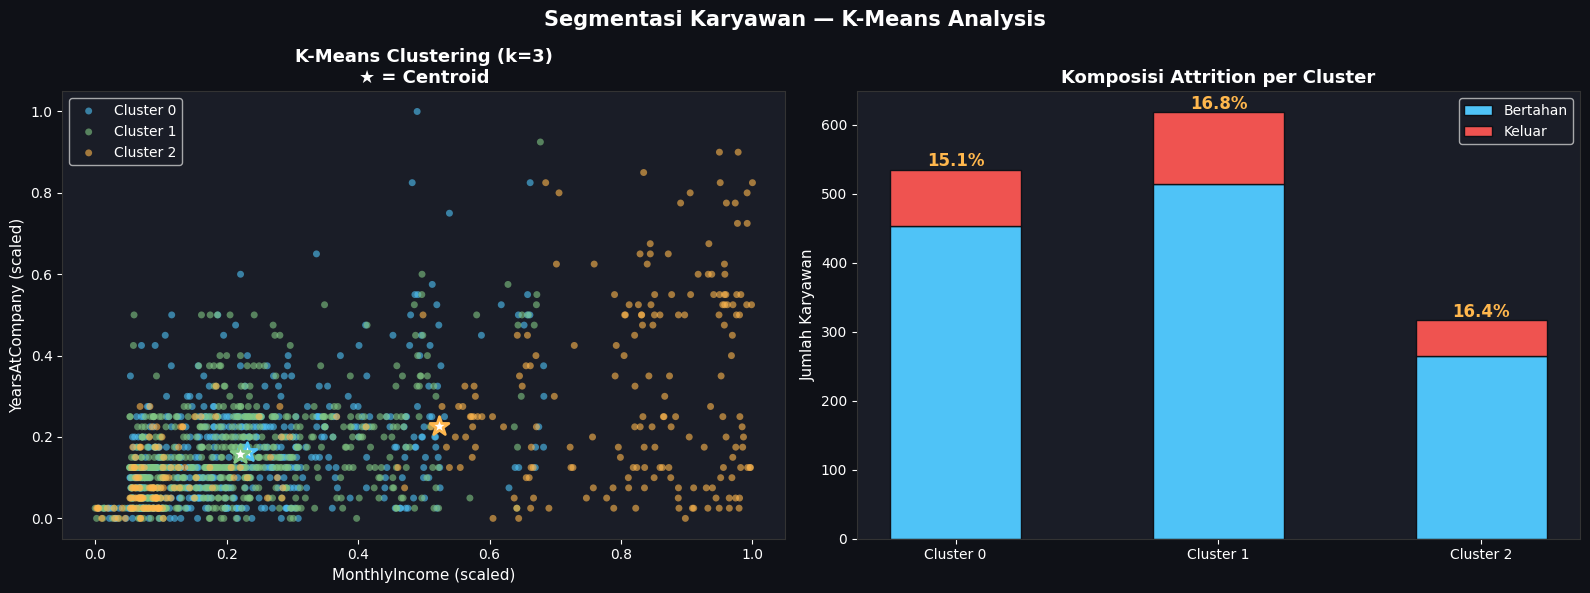

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col as F_col, sum as F_sum, count as F_count

df_plot = df_clustered.select(
    vector_to_array("features").alias("f"),
    "prediction", "left_company"
).toPandas()

df_plot["MonthlyIncome_s"]  = df_plot["f"].apply(lambda x: x[1])
df_plot["YearsAtCompany_s"] = df_plot["f"].apply(lambda x: x[5])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0f1117')
for ax in axes:
    ax.set_facecolor('#1a1d27')

cluster_colors = ['#4fc3f7', '#81c784', '#ffb74d', '#ce93d8', '#ef5350']

for c in range(K_OPTIMAL):
    mask = df_plot["prediction"] == c
    axes[0].scatter(df_plot.loc[mask, "MonthlyIncome_s"],
                    df_plot.loc[mask, "YearsAtCompany_s"],
                    c=cluster_colors[c], label=f"Cluster {c}",
                    alpha=0.6, s=25, edgecolors='none')

centers = km_model.clusterCenters()
for i, center in enumerate(centers):
    axes[0].scatter(center[1], center[5], c='white', s=200, marker='*',
                    edgecolors=cluster_colors[i], linewidths=2, zorder=10)

axes[0].set_xlabel('MonthlyIncome (scaled)', color='white', fontsize=11)
axes[0].set_ylabel('YearsAtCompany (scaled)', color='white', fontsize=11)
axes[0].set_title(f'K-Means Clustering (k={K_OPTIMAL})\n★ = Centroid', color='white', fontsize=13, fontweight='bold')
axes[0].tick_params(colors='white')
axes[0].legend(facecolor='#1a1d27', labelcolor='white')
for spine in axes[0].spines.values():
    spine.set_edgecolor('#333')

# ── Fix aggregasi: eksplisit pakai nama kolom ──
cluster_pd = df_clustered.groupBy("prediction").agg(
    F_sum("left_company").alias("attrition"),
    F_count("*").alias("total")
).toPandas()

cluster_pd = cluster_pd.sort_values("prediction").reset_index(drop=True)
cluster_pd["stay"] = cluster_pd["total"] - cluster_pd["attrition"]
cluster_pd["rate"] = (cluster_pd["attrition"] / cluster_pd["total"] * 100).round(1)

print("Cek data cluster:")
print(cluster_pd)

x = np.arange(K_OPTIMAL)
w = 0.5
axes[1].bar(x, cluster_pd["stay"],      w, label='Bertahan', color='#4fc3f7', edgecolor='#0f1117')
axes[1].bar(x, cluster_pd["attrition"], w, label='Keluar',   color='#ef5350', edgecolor='#0f1117',
            bottom=cluster_pd["stay"])

for i, (_, row) in enumerate(cluster_pd.iterrows()):
    axes[1].text(i, row["total"] + 5, f'{row["rate"]:.1f}%',
                 ha='center', color='#ffb74d', fontsize=12, fontweight='bold')

axes[1].set_xticks(x)
axes[1].set_xticklabels([f'Cluster {c}' for c in cluster_pd["prediction"]], color='white')
axes[1].set_title('Komposisi Attrition per Cluster', color='white', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Jumlah Karyawan', color='white', fontsize=11)
axes[1].tick_params(colors='white')
axes[1].legend(facecolor='#1a1d27', labelcolor='white')
for spine in axes[1].spines.values():
    spine.set_edgecolor('#333')

plt.suptitle('Segmentasi Karyawan — K-Means Analysis', color='white', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('kmeans_clustering.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()